=== [1] CARGA Y PROPIEDADES DEL DATASET ===
• Número total de documentos cargados: 2254
• Categorías objetivo analizadas: ['alt.atheism', 'comp.graphics', 'rec.sport.baseball', 'sci.space']
• Tamaño del vocabulario total extraído: 26064 palabras
• Tamaño del vocabulario seleccionado (max_features): 500 palabras

=== [2] REDUCCIÓN DE DIMENSIONALIDAD Y VARIANZA EXPLICADA ===
• Dimensión de la matriz reducida de trabajo: (2254, 10)
• Varianza explicada por componente: ['0.87%', '1.50%', '1.27%', '1.24%', '0.90%', '0.80%', '0.78%', '0.74%', '0.72%', '0.67%']
• Varianza explicada acumulada por el SVD (10 componentes): 9.50%

=== [3] EVALUACIÓN DE CRITERIOS DE LINKAGE ===
-> Silhouette Score (Criterio WARD)    : 0.1565
-> Silhouette Score (Criterio COMPLETE): 0.2073
📢 CONCLUSIÓN MATEMÁTICA: El criterio con MÁS ÉXITO es: COMPLETE

=== [4] DISTRIBUCIÓN DE LOS CLÚSTERES ===
• Distribución de documentos usando enlace WARD:
  - Clúster 1: 293 documentos (13.0%)
  - Clúster 2: 201 documentos (8.9%

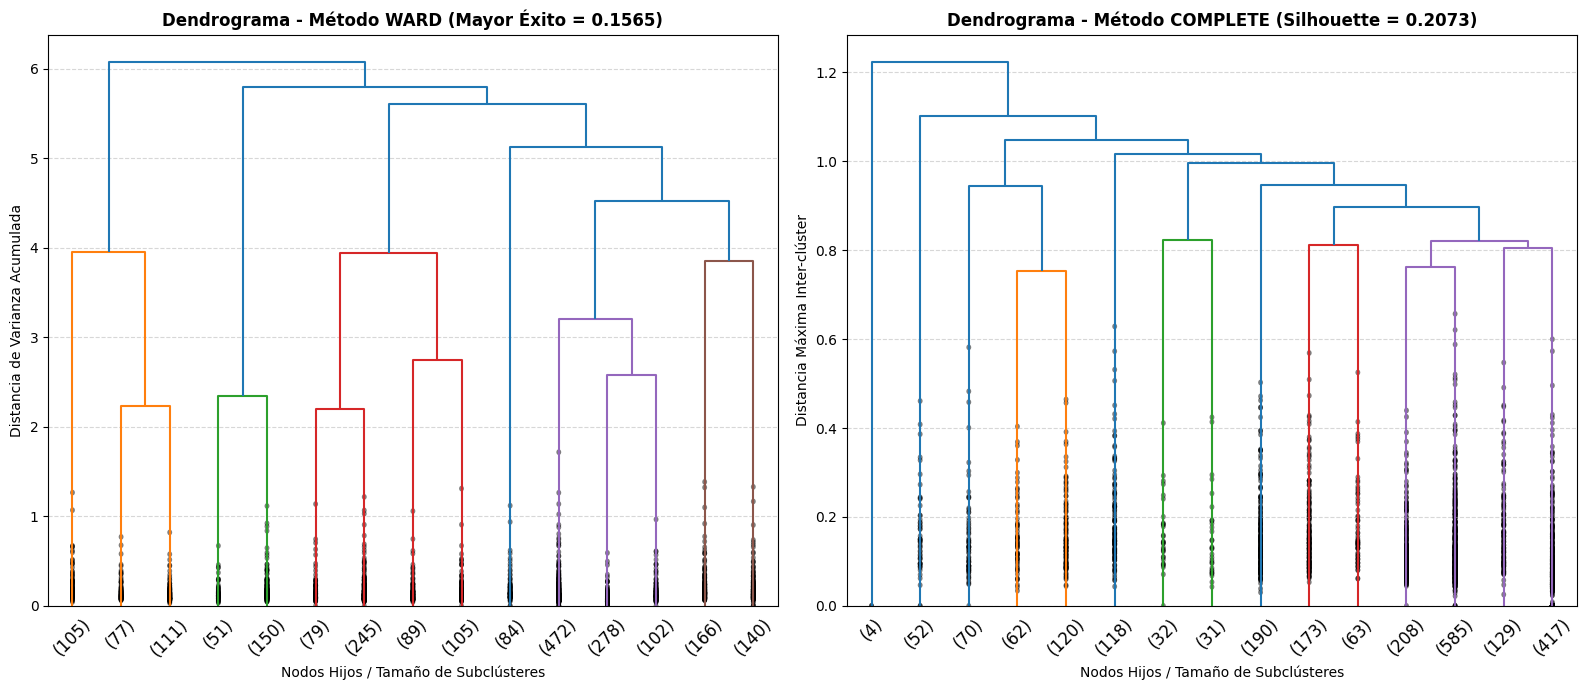

In [4]:
# ===============================================================
# ACTIVIDAD 05: CLUSTERING JERÁRQUICO EN 20 NEWSGROUPS DATASET
# ===============================================================

import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.metrics import silhouette_score

print("=== [1] CARGA Y PROPIEDADES DEL DATASET ===")
# Seleccionamos 4 categorías distintas para analizar la capacidad de separación semántica
categories = ['alt.atheism', 'comp.graphics', 'sci.space', 'rec.sport.baseball']
data = fetch_20newsgroups(subset='train', categories=categories, remove=('headers', 'footers', 'quotes'))

# Mostrar información del dataset solicitado
print(f"• Número total de documentos cargados: {len(data.data)}")
print(f"• Categorías objetivo analizadas: {data.target_names}")

# Vectorización TF-IDF para analizar tamaño del vocabulario
tfidf_completo = TfidfVectorizer(stop_words='english')
X_completo = tfidf_completo.fit_transform(data.data)
vocab_total = len(tfidf_completo.vocabulary_)

# Vectorización con límite de características
tfidf = TfidfVectorizer(max_features=500, stop_words='english')
X_tfidf = tfidf.fit_transform(data.data).toarray()

print(f"• Tamaño del vocabulario total extraído: {vocab_total} palabras")
print(f"• Tamaño del vocabulario seleccionado (max_features): {X_tfidf.shape[1]} palabras")


print("\n=== [2] REDUCCIÓN DE DIMENSIONALIDAD Y VARIANZA EXPLICADA ===")
# Reducción de dimensionalidad con SVD (Latent Semantic Analysis)
n_comp = 10
svd = TruncatedSVD(n_components=n_comp, random_state=42)
X_reduced = svd.fit_transform(X_tfidf)

# Cálculo de la varianza explicada solicitado
varianza_individual = svd.explained_variance_ratio_
varianza_acumulada = np.sum(varianza_individual)

print(f"• Dimensión de la matriz reducida de trabajo: {X_reduced.shape}")
print(f"• Varianza explicada por componente: {['{:.2f}%'.format(v*100) for v in varianza_individual]}")
print(f"• Varianza explicada acumulada por el SVD ({n_comp} componentes): {varianza_acumulada*100:.2f}%")


print("\n=== [3] EVALUACIÓN DE CRITERIOS DE LINKAGE ===")
# Ejecución de los dos criterios de enlace solicitados
Z_ward = linkage(X_reduced, method='ward')
Z_complete = linkage(X_reduced, method='complete')

# Asignación de etiquetas asumiendo k=4 clústeres para la comparación
labels_ward = fcluster(Z_ward, t=4, criterion='maxclust')
labels_complete = fcluster(Z_complete, t=4, criterion='maxclust')

# Cálculo del Coeficiente de Silueta para determinar el éxito de cada uno
score_ward = silhouette_score(X_reduced, labels_ward)
score_complete = silhouette_score(X_reduced, labels_complete)

print(f"-> Silhouette Score (Criterio WARD)    : {score_ward:.4f}")
print(f"-> Silhouette Score (Criterio COMPLETE): {score_complete:.4f}")

# Determinar automáticamente el método más exitoso
exito = "WARD" if score_ward > score_complete else "COMPLETE"
print(f"📢 CONCLUSIÓN MATEMÁTICA: El criterio con MÁS ÉXITO es: {exito}")


print("\n=== [4] DISTRIBUCIÓN DE LOS CLÚSTERES ===")
# Mostrar la distribución de clústeres solicitada utilizando Counter
dist_ward = Counter(labels_ward)
dist_complete = Counter(labels_complete)

print("• Distribución de documentos usando enlace WARD:")
for cluster_id, count in sorted(dist_ward.items()):
    print(f"  - Clúster {cluster_id}: {count} documentos ({count/len(labels_ward)*100:.1f}%)")

print("\n• Distribución de documentos usando enlace COMPLETE:")
for cluster_id, count in sorted(dist_complete.items()):
    print(f"  - Clúster {cluster_id}: {count} documentos ({count/len(labels_complete)*100:.1f}%)")


print("\n=== [5] GENERACIÓN DE DENDROGRAMAS COMPARATIVOS ===")
# Graficación de los árboles jerárquicos
plt.figure(figsize=(16, 7))

# Dendrograma del Criterio Ward
plt.subplot(1, 2, 1)
dendrogram(Z_ward, truncate_mode='lastp', p=15, leaf_rotation=45, show_contracted=True)
plt.title(f"Dendrograma - Método WARD (Mayor Éxito = {score_ward:.4f})", fontsize=12, fontweight='bold')
plt.xlabel("Nodos Hijos / Tamaño de Subclústeres")
plt.ylabel("Distancia de Varianza Acumulada")
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Dendrograma del Criterio Complete
plt.subplot(1, 2, 2)
dendrogram(Z_complete, truncate_mode='lastp', p=15, leaf_rotation=45, show_contracted=True)
plt.title(f"Dendrograma - Método COMPLETE (Silhouette = {score_complete:.4f})", fontsize=12, fontweight='bold')
plt.xlabel("Nodos Hijos / Tamaño de Subclústeres")
plt.ylabel("Distancia Máxima Inter-clúster")
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()